<a href="https://colab.research.google.com/github/OpokuManuel/Amazon_Sales_Analysis/blob/main/Amazon_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Loading dataset
df = pd.read_csv("Amazon.csv")
print("Load Successful")



Load Successful


In [ ]:
# Printing he top-5 records
print("First-5 Records")
df.head()

First-5 Records


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


# Dataset Overview

In [ ]:
#Displaying the number of rows and column
print(f"Dataset Shape: {df.shape}\n with {df.shape[0]} rows and {df.shape[1]} columns")

Dataset Shape: (100000, 20)
 with 100000 rows and 20 columns


In [ ]:
#Displaying all column names
df.columns.tolist()

['OrderID',
 'OrderDate',
 'CustomerID',
 'CustomerName',
 'ProductID',
 'ProductName',
 'Category',
 'Brand',
 'Quantity',
 'UnitPrice',
 'Discount',
 'Tax',
 'ShippingCost',
 'TotalAmount',
 'PaymentMethod',
 'OrderStatus',
 'City',
 'State',
 'Country',
 'SellerID']

In [ ]:
#Viewing the datatypes of the various columns
df.dtypes

OrderID              str
OrderDate            str
CustomerID           str
CustomerName         str
ProductID            str
ProductName          str
Category             str
Brand                str
Quantity           int64
UnitPrice        float64
Discount         float64
Tax              float64
ShippingCost     float64
TotalAmount      float64
PaymentMethod        str
OrderStatus          str
City                 str
State                str
Country              str
SellerID             str
dtype: object

In [ ]:
#STATISTICAL SUMMARY OF DATA
df.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


# KPI ANALYSIS

In [ ]:
#Creating the Sales column from the available columns
df["Profit"] = df["TotalAmount"] - df["Discount"] - df["Tax"] - df["ShippingCost"]
df["Profit"]

0         319.77
1         238.75
2          94.48
3         142.56
4         773.21
          ...   
99995     984.68
99996    2246.50
99997     929.60
99998     294.05
99999     791.78
Name: Profit, Length: 100000, dtype: float64

In [ ]:
#CALCULATING KPIs
total_sales = df["TotalAmount"].sum()
total_profit = df["Profit"].sum()
total_orders = df["OrderID"].count() #let's see if this works
average_sales = df["TotalAmount"].mean()
average_profit = df["Profit"].mean()
max_sales = df["TotalAmount"].max()
min_sales = df["TotalAmount"].min()

In [ ]:
#DISPLAYING KPI RESULTS
print(f"Total Sales: $ {total_sales:,.2f}")
print(f"Total Profit: $ {total_profit:,.2f}")
print(f"Total Orders: $ {total_orders:,.2f}")
print(f"Average Sales: $ {average_sales:,.2f}")
print(f"Average Profit: $ {average_profit:,.2f}")
print(f"Maximum Sales: $ {max_sales:,.2f}")
print(f"Minimum Sales: $ {min_sales:.2f}")

Total Sales: $ 91,825,647.92
Total Profit: $ 84,230,669.15
Total Orders: $ 100,000.00
Average Sales: $ 918.26
Average Profit: $ 842.31
Maximum Sales: $ 3,534.98
Minimum Sales: $ 4.27


# SALES ANALYSIS

In [ ]:
#Total Sales by State
#->State becomes a row if the .reset_index() is not used in the line below and not a column as should be
sales_by_state = df.groupby("State")["TotalAmount"].sum().sort_values(ascending=False).reset_index()

#Renaming columns for clarity
sales_by_state.columns = ["State", "TotalSales"]

print(sales_by_state)

   State   TotalSales
0     TX  22862540.54
1     CA  18231196.79
2     NC   4747701.73
3     WA   4660962.17
4     PA   4650673.88
5     CO   4638498.97
6     IL   4632847.44
7     OH   4615442.32
8     IN   4609048.43
9     FL   4597177.27
10    NY   4554358.08
11    DC   4520876.11
12    AZ   4504324.19


In [ ]:
#Generating Sales by Category
sales_by_cagegory = df.groupby("Category")["TotalAmount"].sum().sort_values(ascending= True).reset_index()

#Renaming columns for clarity
sales_by_cagegory.columns = ["Category", "TotalSales"]

print(sales_by_cagegory)

            Category   TotalSales
0     Home & Kitchen  15163939.36
1       Toys & Games  15216684.99
2           Clothing  15253397.50
3              Books  15261837.01
4  Sports & Outdoors  15345571.88
5        Electronics  15584217.18


In [ ]:
#Generating total sales by sub-category
sub_cat_sales = df.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending= False).reset_index()

sub_cat_sales.columns = ["Sub-Category (ProductName)", "TotalSales"]

print(sub_cat_sales)
print()
print(sub_cat_sales.max())

#verifying max product
# if sub_cat_sales.max()[0] == "Memory Card 128GB":
#     print("MemoryCard")
# elif sub_cat_sales == "Yoga Mat":
#     print("Yoga Mat")
# else:
#     print("UNKNOWN")

     Sub-Category (ProductName)  TotalSales
0             Memory Card 128GB  1935138.40
1                 LED Desk Lamp  1921948.41
2           Mechanical Keyboard  1906963.54
3               Electric Kettle  1905751.79
4                    Smartwatch  1901275.59
5                   Dress Shirt  1896765.36
6                  Water Bottle  1895467.95
7                  Gaming Mouse  1895103.98
8                  Kids Toy Car  1891082.43
9                         Jeans  1882591.82
10  Noise Cancelling Headphones  1881108.57
11                 Cookware Set  1877038.73
12              Smartphone Case  1875421.41
13                   Microphone  1871740.68
14             Smart Light Bulb  1868940.58
15                   4K Monitor  1866774.35
16                 Phone Tripod  1866256.31
17                   Board Game  1863310.96
18               Vacuum Cleaner  1855117.83
19                       Router  1850756.20
20                Laptop Sleeve  1848297.80
21                     Yoga Mat 

# CUSTOMER AND PRODUCT ANALYSIS


In [ ]:
#Top Customers based on sales

top_5_customers = df.groupby("CustomerID")["TotalAmount"].sum().sort_values(ascending=False).reset_index()

top_5_customers.columns = ["CustomerID", "TotalSales"]

print(top_5_customers.head())


   CustomerID  TotalSales
0  CUST023748    15215.79
1  CUST009614    12160.96
2  CUST034178    11418.88
3  CUST001153    11282.96
4  CUST004883    11214.44


In [ ]:
#Total Quantity Sold for each product
quantity_per_product = df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).reset_index()

quantity_per_product.columns = ["ProductName", "Quantity"]

print(quantity_per_product)

                    ProductName  Quantity
0                 LED Desk Lamp      6344
1                  Water Bottle      6275
2             Memory Card 128GB      6240
3                        Router      6202
4                    Board Game      6200
5                    Microphone      6196
6                  Gaming Mouse      6170
7               Electric Kettle      6165
8           Mechanical Keyboard      6161
9                Vacuum Cleaner      6139
10                 Kids Toy Car      6131
11             Smart Light Bulb      6131
12                 Cookware Set      6130
13                   4K Monitor      6111
14                Action Camera      6104
15  Noise Cancelling Headphones      6091
16               Desk Organizer      6079
17             Wireless Charger      6079
18                     Yoga Mat      6077
19              Smartphone Case      6060
20                        Jeans      6037
21                  Instant Pot      6016
22             Wireless Earbuds   

# PAYMENT ANALYSIS

In [ ]:
#Number of orders placed based on payment method

orders_by_payment = df.groupby("PaymentMethod")["OrderID"].count().sort_values(ascending=False).reset_index()

orders_by_payment.columns = ["Payment Method", "NumberOfOrders"]

print(orders_by_payment)

     Payment Method  NumberOfOrders
0       Credit Card           35038
1        Debit Card           20024
2               UPI           15066
3        Amazon Pay           15017
4       Net Banking            9927
5  Cash on Delivery            4928


In [ ]:
#Calculating the Monthly Sales trend using the order date

#Making sure date is in the right order(format)
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
monthly_sales = df.groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"].sum().reset_index()

monthly_sales.columns = ["Month", "TotalSales"]

monthly_sales = monthly_sales.sort_values("Month")

print(monthly_sales)

      Month  TotalSales
0   2020-01  1637069.40
1   2020-02  1339388.21
2   2020-03  1587125.66
3   2020-04  1588347.29
4   2020-05  1533834.17
5   2020-06  1500269.29
6   2020-07  1552981.94
7   2020-08  1640874.93
8   2020-09  1554682.21
9   2020-10  1515403.62
10  2020-11  1502232.24
11  2020-12  1577655.06
12  2021-01  1575253.23
13  2021-02  1425365.99
14  2021-03  1484165.89
15  2021-04  1470885.02
16  2021-05  1571842.25
17  2021-06  1593398.08
18  2021-07  1596668.40
19  2021-08  1545324.30
20  2021-09  1534912.30
21  2021-10  1511118.44
22  2021-11  1419480.77
23  2021-12  1520160.14
24  2022-01  1609759.87
25  2022-02  1369866.29
26  2022-03  1589809.35
27  2022-04  1515497.24
28  2022-05  1527845.26
29  2022-06  1533829.81
30  2022-07  1556516.29
31  2022-08  1541701.50
32  2022-09  1457859.60
33  2022-10  1534349.51
34  2022-11  1525937.46
35  2022-12  1604276.23
36  2023-01  1567772.07
37  2023-02  1384957.09
38  2023-03  1557146.56
39  2023-04  1560322.12
40  2023-05  158

# Multi-level Analysis

In [ ]:
# Sales generated by each state for every category

state_category_sales = df.groupby(["State", "Category"])["TotalAmount"].sum().reset_index()

# Sort the results for better readability (State alphabetically, Sales highest to lowest)
state_category_sales = state_category_sales.sort_values(by=["State", "TotalAmount"], ascending=[True, False])
state_category_sales.columns = ["State", "Category", "Total Sales"]

print(state_category_sales)

   State           Category  Total Sales
5     AZ       Toys & Games    839973.27
0     AZ              Books    793211.33
2     AZ        Electronics    747955.37
3     AZ     Home & Kitchen    737616.34
4     AZ  Sports & Outdoors    694318.06
..   ...                ...          ...
75    WA     Home & Kitchen    809448.28
76    WA  Sports & Outdoors    807282.60
73    WA           Clothing    747668.70
77    WA       Toys & Games    711514.12
72    WA              Books    705467.57

[78 rows x 3 columns]


# VISUALIZATION

C:\Users\attam\AppData\Local\Temp\ipykernel_32944\1313075214.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_chart = sns.barplot(x="State", y="TotalAmount", data=state_sales, palette="Blues_r")


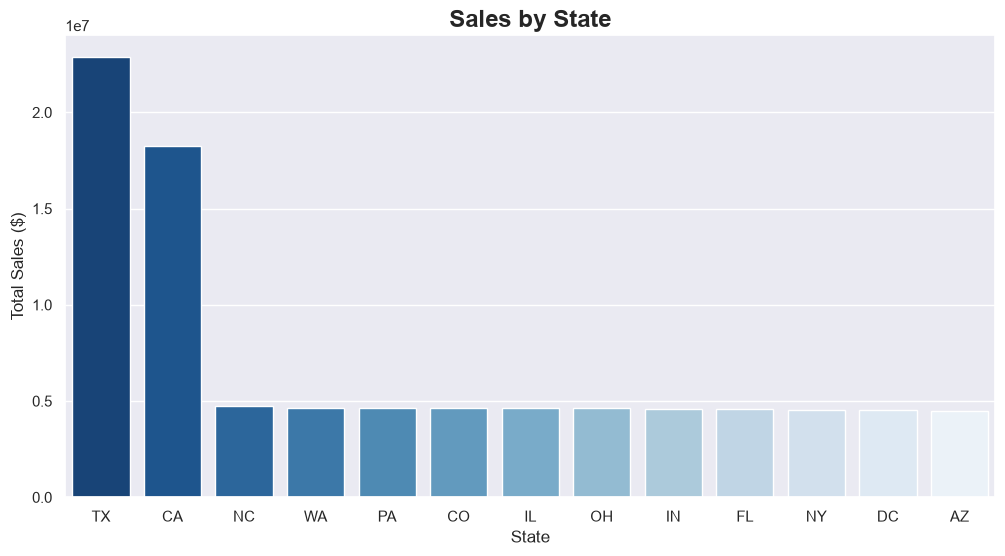

In [ ]:
#Creating A Bar Chart based on sales by state

state_sales = df.groupby("State")["TotalAmount"].sum().sort_values(ascending=False).reset_index()

# using seaborne to set chart dimension
sns.set_theme(rc={"figure.figsize": (12,6)})

#plotting barchart
bar_chart = sns.barplot(x="State", y="TotalAmount", data=state_sales, palette="Blues_r")

#customize titles and axes labels
bar_chart.set_title("Sales by State", fontsize=17, fontweight="bold")
bar_chart.set_xlabel("State", fontsize=12)
bar_chart.set_ylabel("Total Sales ($)", fontsize=12)

#saving the chart as an image
plt.savefig("sales_by_state.png", bbox_inches="tight", dpi=300)

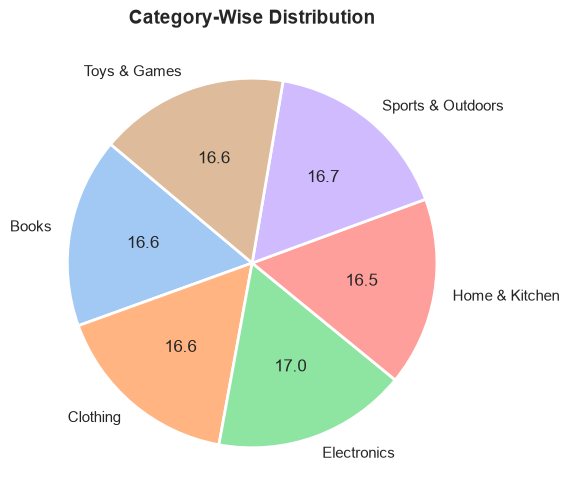

In [ ]:
#Creating a Pie Chart showcasing Category-wise Sales
category_sales = df.groupby("Category")["TotalAmount"].sum().reset_index()

#Setting the color palette for the category count
colors = sns.color_palette("pastel")[0:len(category_sales)]



# Plotting the Pie Chart
plt.pie(
    category_sales["TotalAmount"],
    labels = category_sales["Category"],
    autopct = "%1.1f",
    startangle = 140,
    colors = colors,
    wedgeprops = {"edgecolor":"white", "linewidth":2.0}
)

# Displaying a Bold Title for Clarification
plt.title("Category-Wise Distribution", fontsize=14, fontweight="bold")

# Saving the chart as an image
plt.savefig("state_category_sales.png", bbox_inches="tight", dpi=300)

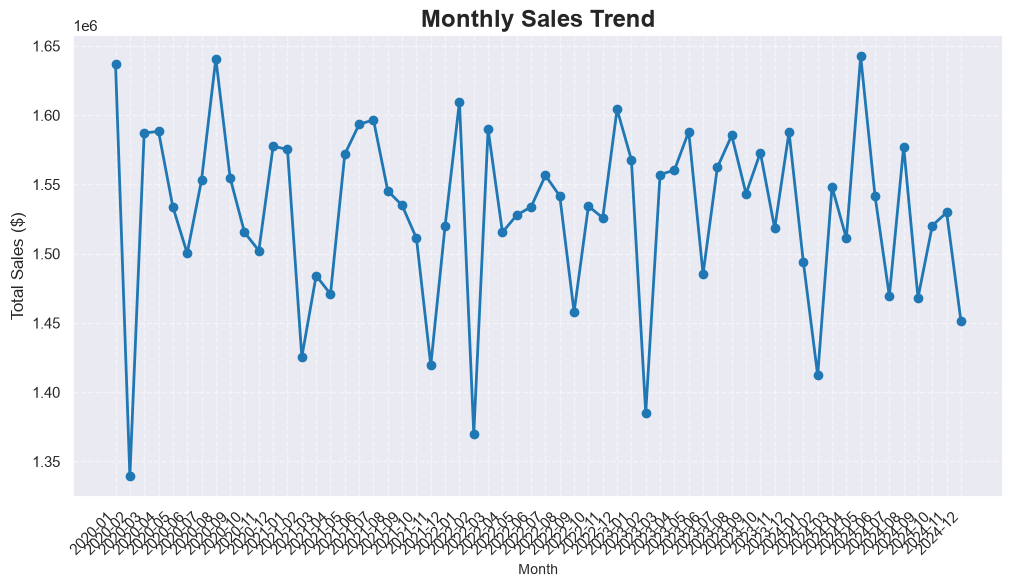

In [ ]:
# 1. Recalculate monthly sales trend (converting Period to string for proper plotting)
monthly_sales = df.groupby(df['OrderDate'].dt.to_period('M'))['TotalAmount'].sum().reset_index()
monthly_sales.columns = ['Month', 'Total Sales']
monthly_sales = monthly_sales.sort_values('Month')
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

# 2. Plot the line chart
plt.plot(monthly_sales['Month'], monthly_sales['Total Sales'], marker='o', color='#1f77b4', linewidth=2)

# 3. Customize titles, labels, and grid
plt.title('Monthly Sales Trend', fontsize=17, fontweight='bold')
plt.xlabel('Month', fontsize=10)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Rotate x-axis labels to prevent overlapping
plt.xticks(rotation=45, ha='right')

# 4. Save the chart as an image
plt.savefig('monthly_sales_trend.png', bbox_inches='tight', dpi=300)

C:\Users\attam\AppData\Local\Temp\ipykernel_32944\1731653230.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='TotalAmount', y='ProductName', data=top_10_products, palette='Blues_r')


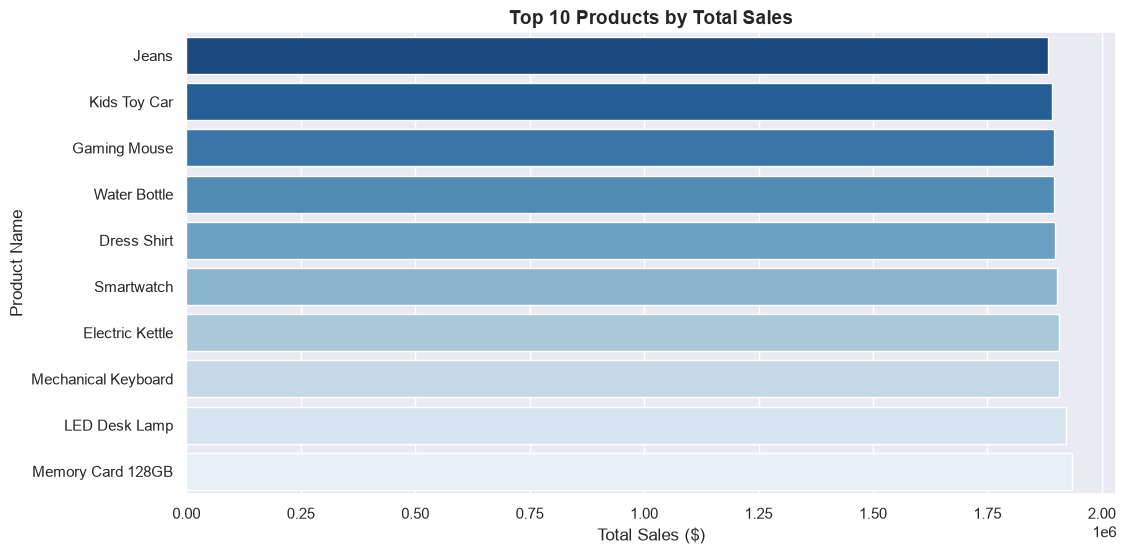

In [ ]:
# 1. Group by ProductName, sum the TotalAmount, and get the top 10
top_10_products = df.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=True).tail(10).reset_index()

# 2. Set chart dimensions
sns.set_theme(rc={'figure.figsize':(12, 6)})

# 3. Plot horizontal bar chart (notice y='ProductName' and x='TotalAmount')
ax = sns.barplot(x='TotalAmount', y='ProductName', data=top_10_products, palette='Blues_r')

# 4. Customize titles and axes labels
ax.set_title('Top 10 Products by Total Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)', fontsize=12)
ax.set_ylabel('Product Name', fontsize=12)

# 5. Save the chart as an image
plt.savefig('top_10_products_sales.png', bbox_inches='tight', dpi=300)